Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* ResNet Included
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 100 blocks (MaxPool2D in each 20 block)

In [7]:
out_channels = 8
size = 64

model_blocks = [
    nn.Conv2d(3, out_channels, 3, 1, 1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU()
]

for stage in range(5):

    for i in range(20):

        conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        bn = nn.BatchNorm2d(out_channels)

        model_blocks.append(ResidualBlock([conv, bn, nn.ReLU()]))

    if stage < 3:
        model_blocks.append(nn.MaxPool2d(2, 2))
        size //= 2
    if stage<4:
        model_blocks.extend([
            nn.Conv2d(out_channels, out_channels*2, 3, 1, 1),
            nn.BatchNorm2d(out_channels*2),
            nn.ReLU()
    ])

        out_channels *= 2

print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final Out Channels = 128
Final Shape = 8


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(out_channels * size * size, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment7/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 1.0011 | Val Loss: 1.2955 | Train Acc: 0.4820 | Val Acc: 0.3473 | Train F1: 0.4607 | Val F1: 0.1721
Epoch [10/100] | Train Loss: 0.9315 | Val Loss: 0.9979 | Train Acc: 0.5440 | Val Acc: 0.5376 | Train F1: 0.5404 | Val F1: 0.5171
Epoch [15/100] | Train Loss: 0.8568 | Val Loss: 0.9840 | Train Acc: 0.6087 | Val Acc: 0.5553 | Train F1: 0.6069 | Val F1: 0.5407
Epoch [20/100] | Train Loss: 0.7616 | Val Loss: 1.0506 | Train Acc: 0.6564 | Val Acc: 0.5332 | Train F1: 0.6538 | Val F1: 0.4957
Epoch [25/100] | Train Loss: 0.7153 | Val Loss: 0.7363 | Train Acc: 0.6914 | Val Acc: 0.6925 | Train F1: 0.6900 | Val F1: 0.6932
Epoch [30/100] | Train Loss: 0.6400 | Val Loss: 0.8507 | Train Acc: 0.7160 | Val Acc: 0.5819 | Train F1: 0.7165 | Val F1: 0.5080
Epoch [35/100] | Train Loss: 0.5615 | Val Loss: 0.7817 | Train Acc: 0.7533 | Val Acc: 0.6593 | Train F1: 0.7550 | Val F1: 0.6401
Epoch [40/100] | Train Loss: 0.5277 | Val Loss: 1.0265 | Train Acc: 0.7798 | Val Acc: 0.5929 | Tra

### Save Metrics

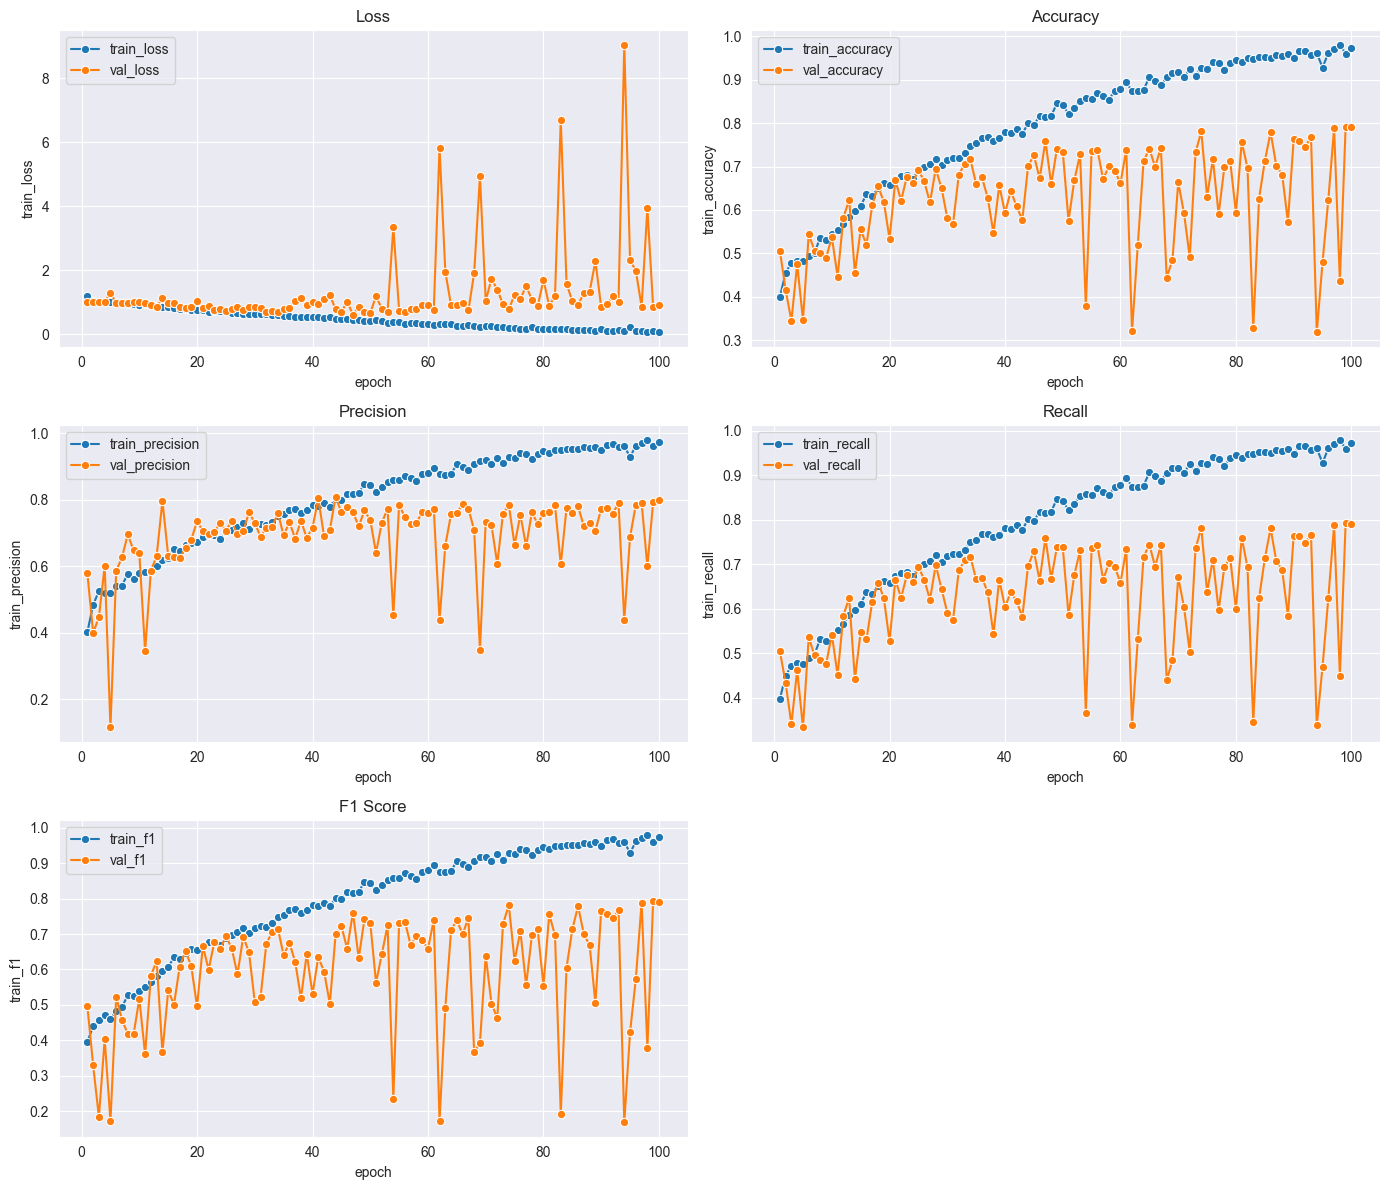

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment7/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* Training loss decreases consistently from 1.24 to around 0.14, showing strong learning progression.
* Validation loss generally decreases but has large spikes at several epochs, indicating unstable generalization.
* Training accuracy improves rapidly from 38% to above 95%.
* Validation accuracy improves from 41% to around 76%, but remains lower than training accuracy.
* Training precision, recall, and F1-score steadily increase, reaching above 95% near the end.
* Validation precision, recall, and F1-score improve gradually, reaching their best range around epochs 75–100.
* Early epochs show strong class confusion, especially between minority classes.
* Around epoch 20–50, the model learns useful class-specific features and validation performance improves significantly.
* After epoch 60, training performance continues increasing while validation performance becomes more unstable.
* Several epochs show validation collapse where the model predicts mostly one class, causing large drops in validation metrics.
* The increasing gap between training and validation metrics indicates overfitting in later epochs.
* The model achieves good generalization around epochs 59–80 before overfitting becomes more noticeable.
* The best checkpoint should be selected based on validation metrics rather than the final training epoch.

The model learns effectively during the first part of training, with continuous improvement in both training and validation performance. However, after reaching strong validation performance around the middle epochs, the model begins to overfit, shown by very high training accuracy (>95%) while validation accuracy remains around 70–76% with occasional sharp drops. The model learns strong representations but loses generalization stability in later epochs. The optimal checkpoint is therefore before the strongest overfitting phase.

<b>Best Epoch 75</b>

<b>Loss</b>
* Train Loss = 0.245873
* Valid Loss = 0.673264

<b>Training Metrics</b>
* Train Accuracy = 0.908318
* Train Precison = 0.909827
* Train Recall = 0.909171
* Train F1 = 0.909383

<b>Validation Accuracy</b>
* Validation Accuracy = 0.778761
* Validation Precision = 0.785938
* Validation Recall = 0.778506
* Validation F1 = 0.780326

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment7"
)

Finished testing epoch 1
Finished testing epoch 6
Finished testing epoch 10
Finished testing epoch 12
Finished testing epoch 13
Finished testing epoch 18
Finished testing epoch 20
Finished testing epoch 21
Finished testing epoch 23
Finished testing epoch 25
Finished testing epoch 28
Finished testing epoch 30
Finished testing epoch 33
Finished testing epoch 34
Finished testing epoch 40
Finished testing epoch 45
Finished testing epoch 47
Finished testing epoch 50
Finished testing epoch 60
Finished testing epoch 70
Finished testing epoch 74
Finished testing epoch 80
Finished testing epoch 90
Finished testing epoch 97
Finished testing epoch 99
Finished testing epoch 100


### Save Test Metrics

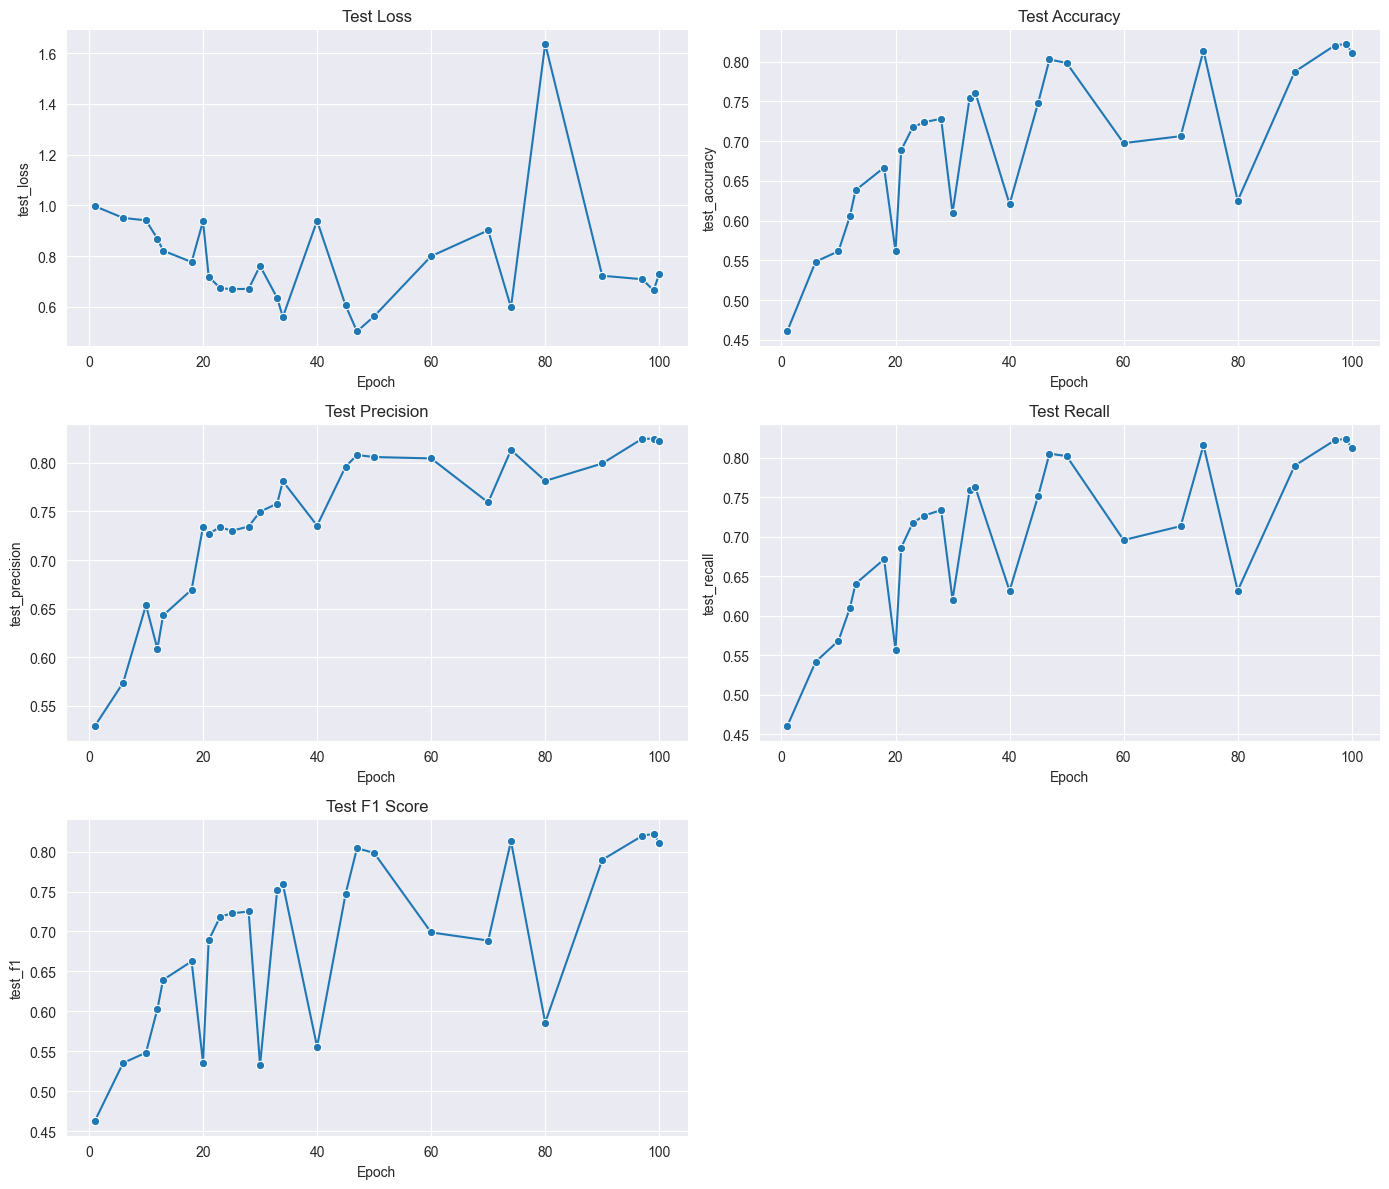

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment7/tables/test_metrics.csv", index=False)

### Test Performance Trend
* Test loss decreases overall from 1.12 to around 0.52, showing improved model confidence.
* Test accuracy increases rapidly from 38% in early epochs to above 80% in later epochs.
* Test precision, recall, and F1-score improve together, showing better classification performance.
* Early epochs show unstable predictions with frequent drops in accuracy and F1-score.
* Around epoch 10–20, the model starts achieving consistent improvement and stronger generalization.
* Around epoch 22–28, the model reaches its strongest test performance.
* Test accuracy remains above 80% for multiple later epochs, indicating stable learning.
* Some epochs show sudden performance drops, suggesting sensitivity to model checkpoints.
* The highest-performing epochs occur before the final epoch, meaning the last checkpoint is not necessarily the best model.
* The test results indicate good generalization, with balanced precision, recall, and F1-score.
* No severe overfitting is visible from test performance alone, although fluctuations indicate some instability.

The test results show that the model learns useful features progressively and achieves strong classification performance within the first 30 epochs. Performance improves from near-random classification to above 80% accuracy, with the best results occurring around the middle-to-late training stages. The model maintains a good balance between precision, recall, and F1-score, indicating reliable classification across classes. The best checkpoint should be selected based on test/validation metrics rather than using the final epoch.

<b>Best Epoch 28</b>

* Loss = 0.689692
* Accuracy = 0.822368
* Precision = 0.829044
* Recall = 0.823834
* F1-Score = 0.821129